<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/Fgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

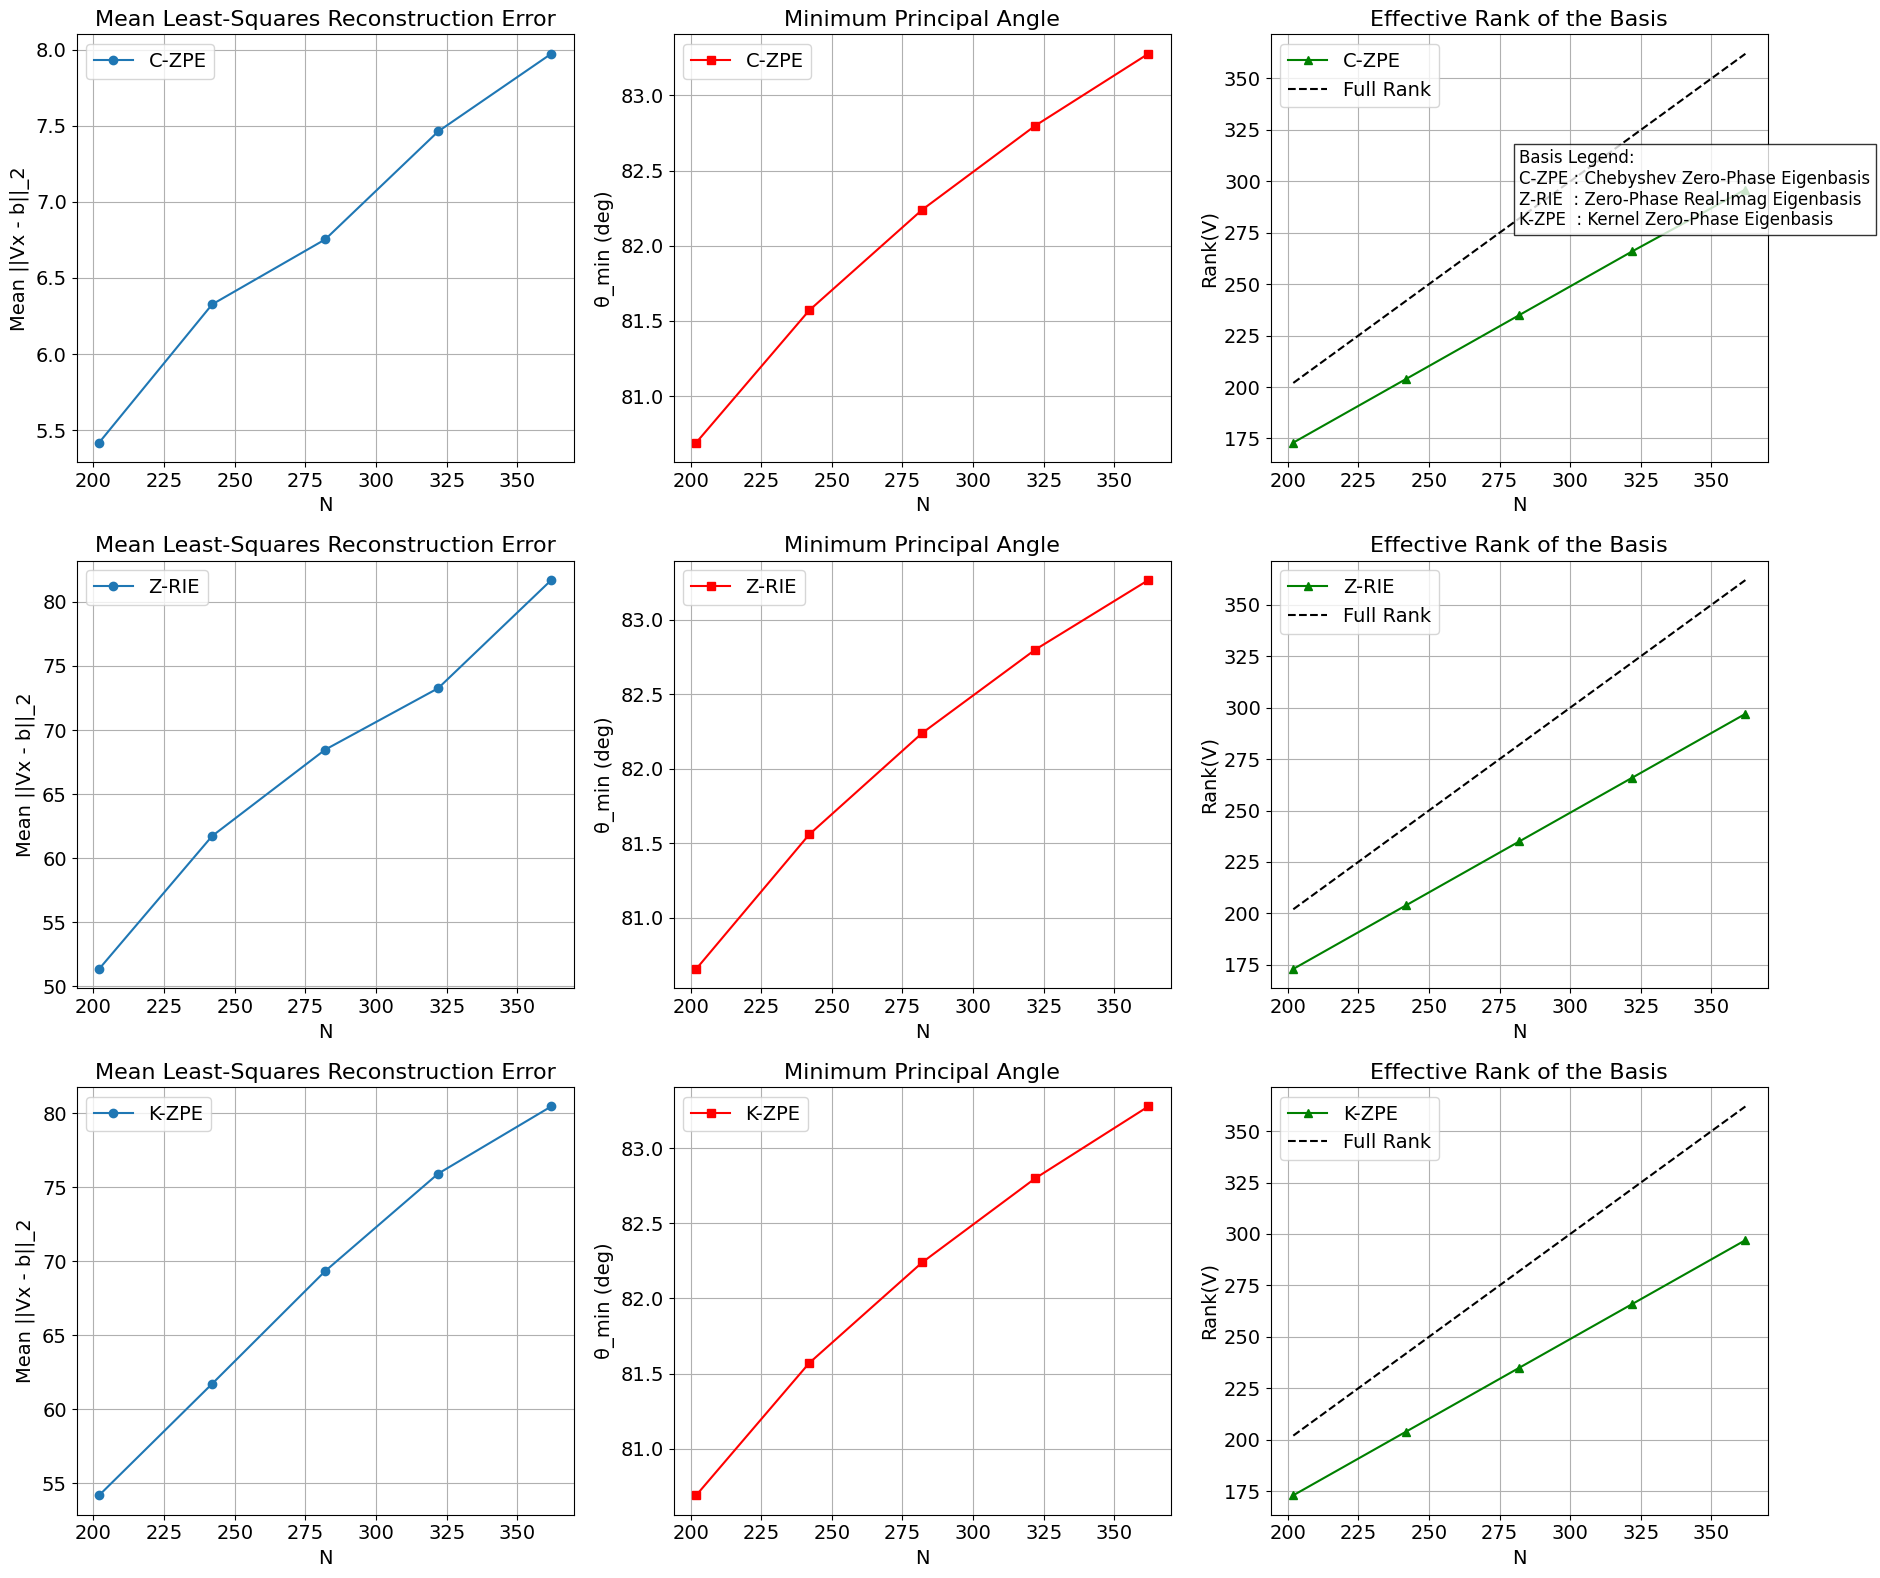

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Utility functions
# ----------------------------
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

# ----------------------------
# m values
# ----------------------------
m_values = np.arange(50, 100, 10)
N_values = 4*m_values + 2  # محاسبه N بر اساس m

# ----------------------------
# Prepare figure with larger fonts
# ----------------------------
plt.figure(figsize=(18, 16))  # 3 rows, 3 columns
plt.rcParams.update({'font.size': 14})  # فونت بزرگ‌تر و مناسب مقاله

# ============================
# PROGRAM 1: Chebyshev Kernel Eigenbasis (K-ZPE)
# ============================
theta_min_vals_1 = []
residual_mean_vals_1 = []
rank_vals_1 = []

for m, N in zip(m_values, N_values):
    theta = 0
    numVectors = N//10

    w = np.exp(-2j * np.pi / N)
    k = np.arange(N).reshape(N,1)
    l = np.arange(N).reshape(1,N)
    G = (1/np.sqrt(N)) * w**((k - theta/2.0) * (l - theta/2.0))

    C = np.real(G)
    S = np.imag(G)

    C2 = C @ C
    S2 = S @ S
    P_1  = 0.25*(C2 + C)
    P_m1 = 0.25*(C2 - C)
    P_i  = 0.25*(S2 + S)
    P_mi = 0.25*(S2 - S)

    X = P_1[:, 0:m+1]
    Y = P_m1[:, 0:m+1]
    Z = P_i[:, 1:m+1]
    T = P_mi[:, 1:m+1]
    V_F_cheby = np.hstack([X, Y, Z, T])

    size_X, size_Y, size_Z, size_T = X.shape[1], Y.shape[1], Z.shape[1], T.shape[1]
    diag_entries = np.hstack([
        np.ones(size_X),
        -np.ones(size_Y),
        1j*np.ones(size_Z),
        -1j*np.ones(size_T)
    ])
    D = np.diag(diag_entries)

    residual_norms = []
    for _ in range(numVectors):
        b = np.random.randn(N)
        x = np.linalg.lstsq(V_F_cheby, b, rcond=None)[0]
        residual_norms.append(np.linalg.norm(V_F_cheby @ x - b))
    residual_mean_vals_1.append(np.mean(residual_norms))

    Vn = normalize_columns(V_F_cheby)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:,i], Vn[:,j]), -1.0, 1.0)
            angle = np.arccos(inner)
            min_angle = min(min_angle, angle)
    theta_min_vals_1.append(np.degrees(min_angle))

    rank_vals_1.append(np.linalg.matrix_rank(V_F_cheby))

# --- Plot Program 1 ---
plt.subplot(3,3,1)
plt.plot(N_values, residual_mean_vals_1, marker='o', label='C-ZPE')
plt.title("Mean Least-Squares Reconstruction Error", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("Mean ||Vx - b||_2", fontsize=14)
plt.grid(True)
plt.legend()

plt.subplot(3,3,2)
plt.plot(N_values, theta_min_vals_1, marker='s', color='red', label='C-ZPE')
plt.title("Minimum Principal Angle", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("θ_min (deg)", fontsize=14)
plt.grid(True)
plt.legend()

plt.subplot(3,3,3)
plt.plot(N_values, rank_vals_1, marker='^', color='green', label='C-ZPE')
plt.plot(N_values, N_values, '--k', label='Full Rank')
plt.title("Effective Rank of the Basis", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("Rank(V)", fontsize=14)
plt.legend()
plt.grid(True)

# ============================
# PROGRAM 2: Real-Imaginary Eigenbasis (RI-E)
# ============================
theta_min_vals_2 = []
residual_mean_vals_2 = []
rank_vals_2 = []

for m, N in zip(m_values, N_values):
    theta = 0
    numVectors = 40

    w = np.exp(-2j * np.pi / N)
    k = np.arange(N).reshape(N,1)
    l = np.arange(N).reshape(1,N)
    G = (1/np.sqrt(N)) * w**((k - theta/2.0)*(l - theta/2.0))

    C = np.real(G)
    S = np.imag(G)

    P = 0.5*np.eye(N)
    P[0,0] = 1
    P[2*m+1, 2*m+1] = 1
    for k_idx in range(1, 2*m+1):
        P[k_idx, N-k_idx] = 0.5
        P[k_idx+2*m+1, N-k_idx-2*m-1] = -0.5

    Ph = P
    Ph_inv = np.linalg.inv(Ph)

    V_tmp = Ph @ C @ Ph_inv
    W_tmp = Ph @ S @ Ph_inv

    A = V_tmp[0:2*m+2, 0:2*m+2]
    B = W_tmp[2*m+2:N, 2*m+2:N]

    X_2 = (A + np.eye(2*m+2))[:, 0:m+1]
    Y_2 = (A - np.eye(2*m+2))[:, 0:m+1]
    Z_2 = (B + np.eye(2*m))[:, 0:m]
    T_2 = (B - np.eye(2*m))[:, 0:m]

    pad_rows_XY = N - X_2.shape[0]
    X_3 = Ph_inv @ np.vstack([X_2, np.zeros((pad_rows_XY, m+1))])
    Y_3 = Ph_inv @ np.vstack([Y_2, np.zeros((pad_rows_XY, m+1))])

    pad_rows_ZT = N - Z_2.shape[0]
    Z_3 = Ph_inv @ np.vstack([np.zeros((pad_rows_ZT, m)), Z_2])
    T_3 = Ph_inv @ np.vstack([np.zeros((pad_rows_ZT, m)), T_2])

    V_F_reim = np.hstack([X_3, Y_3, Z_3, T_3])

    size_X, size_Y, size_Z, size_T = X_3.shape[1], Y_3.shape[1], Z_3.shape[1], T_3.shape[1]
    diag_entries = np.hstack([
        np.ones(size_X),
        -np.ones(size_Y),
        1j*np.ones(size_Z),
        -1j*np.ones(size_T)
    ])
    D_3 = np.diag(diag_entries)

    residual_norms = []
    for _ in range(numVectors):
        b = np.random.randn(N)*10
        x = np.linalg.lstsq(V_F_reim, b, rcond=None)[0]
        residual_norms.append(np.linalg.norm(V_F_reim @ x - b))
    residual_mean_vals_2.append(np.mean(residual_norms))

    Vn = normalize_columns(V_F_reim)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:,i], Vn[:,j]), -1.0, 1.0)
            angle = np.arccos(inner)
            min_angle = min(min_angle, angle)
    theta_min_vals_2.append(np.degrees(min_angle))

    rank_vals_2.append(np.linalg.matrix_rank(V_F_reim))

# --- Plot Program 2 ---
plt.subplot(3,3,4)
plt.plot(N_values, residual_mean_vals_2, marker='o', label='Z-RIE')
plt.title("Mean Least-Squares Reconstruction Error", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("Mean ||Vx - b||_2", fontsize=14)
plt.grid(True)
plt.legend()

plt.subplot(3,3,5)
plt.plot(N_values, theta_min_vals_2, marker='s', color='red', label='Z-RIE')
plt.title("Minimum Principal Angle", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("θ_min (deg)", fontsize=14)
plt.grid(True)
plt.legend()

plt.subplot(3,3,6)
plt.plot(N_values, rank_vals_2, marker='^', color='green', label='Z-RIE')
plt.plot(N_values, N_values, '--k', label='Full Rank')
plt.title("Effective Rank of the Basis", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("Rank(V)", fontsize=14)
plt.legend()
plt.grid(True)

# ============================
# PROGRAM 3: Kernel Matrix Eigenbasis (K-ME)
# ============================
theta_min_vals_3 = []
residual_mean_vals_3 = []
rank_vals_3 = []

for m, N in zip(m_values, N_values):
    w = np.exp(-2j * np.pi / N)
    numVectors = 40

    d = np.ones(2*m+2)
    d[0] = 1/np.sqrt(2)
    d[2*m+1] = 1/np.sqrt(2)

    C = np.zeros((2*m+2, 2*m+2))
    for k_idx in range(2*m+2):
        for l_idx in range(2*m+2):
            C[k_idx,l_idx] = 1/np.sqrt(N) * d[k_idx]*d[l_idx]*np.cos(k_idx*l_idx*2*np.pi/N)

    S = np.zeros((2*m, 2*m))
    for k_idx in range(2*m):
        for l_idx in range(2*m):
            S[k_idx,l_idx] = 1/np.sqrt(N) * np.sin((k_idx+1)*(l_idx+1)*2*np.pi/N)

    X = C + 0.5*np.eye(2*m+2)
    Y = C - 0.5*np.eye(2*m+2)
    Z = S + 0.5*np.eye(2*m)
    T = S - 0.5*np.eye(2*m)

    F = np.zeros((N,N), dtype=complex)
    for k_idx in range(N):
        for l_idx in range(N):
            F[k_idx,l_idx] = 1/np.sqrt(N) * w**(k_idx*l_idx)

    J = np.fliplr(np.eye(2*m))

    X1 = X[:, :m+1]
    Y1 = Y[:, :m+1]
    Z1 = Z[:, :m]
    T1 = T[:, :m]

    X0 = X1[1:2*m+1, :]
    Y0 = Y1[1:2*m+1, :]

    X2 = np.vstack([np.sqrt(2)*X1[0,:], X0, np.sqrt(2)*X1[2*m+1,:], J @ X0])
    Y2 = np.vstack([np.sqrt(2)*Y1[0,:], Y0, np.sqrt(2)*Y1[2*m+1,:], J @ Y0])
    Z2 = np.vstack([np.zeros((1,m)), Z1, np.zeros((1,m)), -J @ Z1])
    T2 = np.vstack([np.zeros((1,m)), T1, np.zeros((1,m)), -J @ T1])

    V_kernelmatrix = np.hstack([X2, Y2, T2, Z2])

    D_2 = np.zeros((N,N), dtype=complex)
    for k_idx in range(m+1):
        D_2[k_idx,k_idx] = 1
        D_2[m+1+k_idx, m+1+k_idx] = -1
    for k_idx in range(m):
        D_2[2*m+2+k_idx, 2*m+2+k_idx] = 1j
        D_2[3*m+2+k_idx, 3*m+2+k_idx] = -1j

    residual_norms = []
    for _ in range(numVectors):
        b = np.random.randn(N)*10
        x = np.linalg.lstsq(V_kernelmatrix, b, rcond=None)[0]
        residual_norms.append(np.linalg.norm(V_kernelmatrix @ x - b))
    residual_mean_vals_3.append(np.mean(residual_norms))

    Vn = normalize_columns(V_kernelmatrix)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:,i], Vn[:,j]), -1.0, 1.0)
            angle = np.arccos(inner)
            min_angle = min(min_angle, angle)
    theta_min_vals_3.append(np.degrees(min_angle))

    rank_vals_3.append(np.linalg.matrix_rank(V_kernelmatrix))

# --- Plot Program 3 ---
plt.subplot(3,3,7)
plt.plot(N_values, residual_mean_vals_3, marker='o', label='K-ZPE')
plt.title("Mean Least-Squares Reconstruction Error", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("Mean ||Vx - b||_2", fontsize=14)
plt.grid(True)
plt.legend()

plt.subplot(3,3,8)
plt.plot(N_values, theta_min_vals_3, marker='s', color='red', label='K-ZPE')
plt.title("Minimum Principal Angle", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("θ_min (deg)", fontsize=14)
plt.grid(True)
plt.legend()

plt.subplot(3,3,9)
plt.plot(N_values, rank_vals_3, marker='^', color='green', label='K-ZPE')
plt.plot(N_values, N_values, '--k', label='Full Rank')
plt.title("Effective Rank of the Basis", fontsize=16)
plt.xlabel("N", fontsize=14)
plt.ylabel("Rank(V)", fontsize=14)
plt.legend()
plt.grid(True)

# ----------------------------
# Add overall figure legend
# ----------------------------
plt.figtext(0.85, 0.9,
            "Basis Legend:\n"
            "C-ZPE : Chebyshev Zero-Phase Eigenbasis\n"
            "Z-RIE  : Zero-Phase Real-Imag Eigenbasis\n"
            "K-ZPE  : Kernel Zero-Phase Eigenbasis",
            fontsize=12, va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.tight_layout()

# ----------------------------
# Save figure as PDF and PNG
# ----------------------------
plt.savefig("basis_analysis.pdf", format='pdf', bbox_inches='tight')
plt.savefig("basis_analysis.png", format='png', dpi=300, bbox_inches='tight')

plt.show()

from google.colab import files

# دانلود PDF
files.download("basis_analysis.pdf")

# دانلود PNG
files.download("basis_analysis.png")

